<a href="https://colab.research.google.com/github/tanmayrathi/ML_PROJECT_TAE1/blob/main/Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# STEP 1: Mount Google Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [40]:
# STEP 2: Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix




In [3]:
# STEP 3: Load Dataset
# =========================
file_path = '/content/drive/MyDrive/ML_datasets/healthcare-dataset-stroke-data.csv'   # change path
df = pd.read_csv(file_path)

print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

First 5 rows:
       id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

Dataset Info:

<class 'pandas.core.frame

In [4]:
# STEP 4: EDA (Exploratory Data Analysis)
# =========================

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Drop missing values (or you can fill them)
df = df.dropna()



Missing Values:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


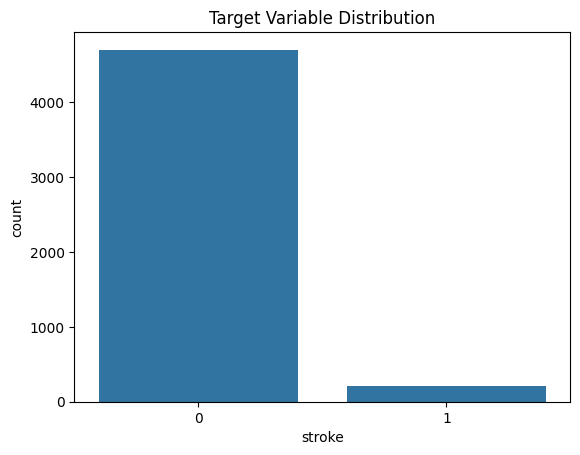

In [5]:
# Visualization 1: Target Distribution
# =========================
plt.figure()
sns.countplot(x=df.iloc[:, -1])   # assumes last column is target
plt.title("Target Variable Distribution")
plt.show()


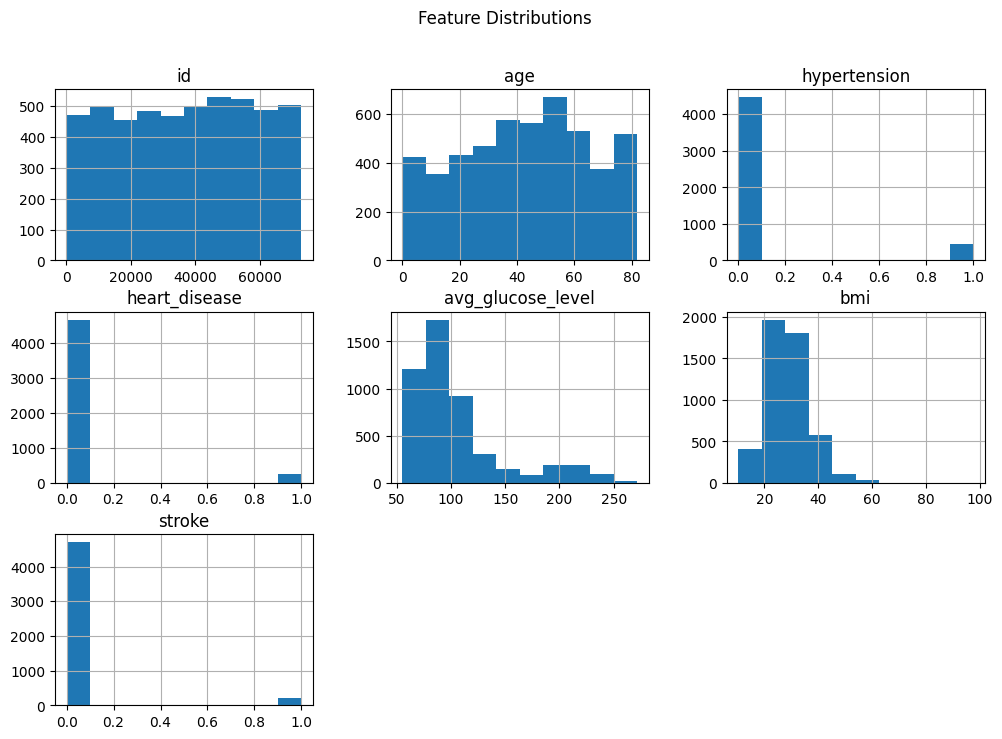

In [6]:
# Visualization 2: Feature Histograms
# =========================
df.hist(figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()


In [8]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

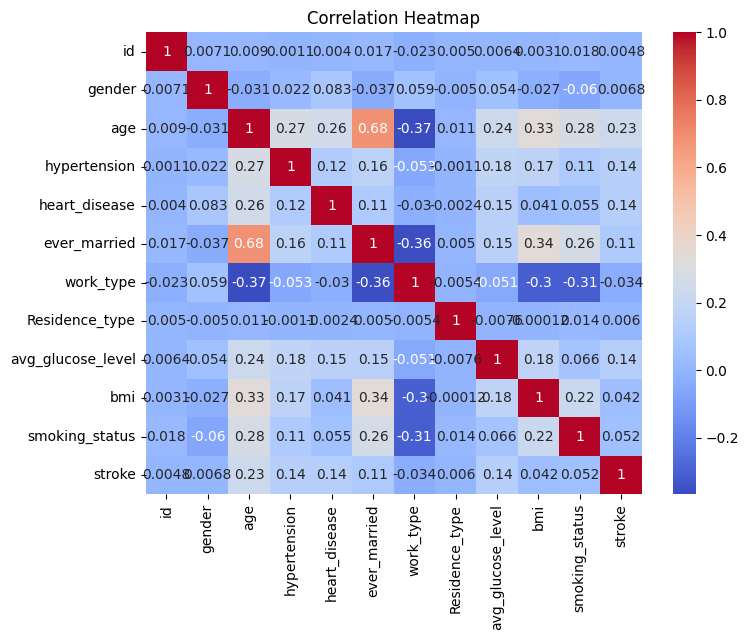

In [9]:
# Visualization 3: Correlation Heatmap
# =========================
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [10]:
# STEP 5: Encoding Categorical Data
# =========================
label_encoders = {}

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [11]:
# STEP 6: Split Features & Target
# =========================
# Replace with your target column name if not last column
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [16]:

# Feature scaling (optional but good practice)
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [19]:
# STEP 7: Train-Test Split Loop
# =========================
split_ratios = [0.3, 0.2]   # 70:30 and 80:20

for test_size in split_ratios:

    print("\n==============================")
    print(f"Train-Test Split: {int((1-test_size)*100)}:{int(test_size*100)}")
    print("==============================")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )



Train-Test Split: 70:30

Train-Test Split: 80:20


In [23]:
 # STEP 8: Naive Bayes Model
    # =========================
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [30]:
 # STEP 9: Prediction
    # =========================
 y_pred = model.predict(X_test)


In [37]:
 # STEP 10: Evaluation
# =========================
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 0.8767820773930753


In [38]:
 print("\nClassification Report:\n")
 print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.90      0.93       929
           1       0.20      0.42      0.27        53

    accuracy                           0.88       982
   macro avg       0.58      0.66      0.60       982
weighted avg       0.92      0.88      0.90       982



In [41]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[839  90]
 [ 31  22]]


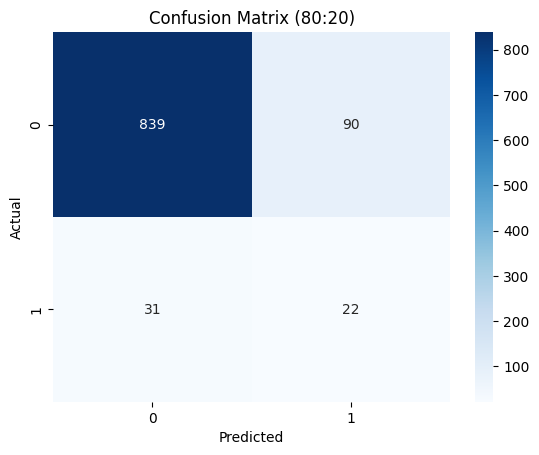

In [43]:
  # STEP 11: Confusion Matrix Visualization
    # =========================
  plt.figure()
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.title(f'Confusion Matrix ({int((1-test_size)*100)}:{int(test_size*100)})')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()